### Lets first load the data into colab

In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.6 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="gXDnajUsrdf5c0k0dw7x")
project = rf.workspace("plywoodv1").project("cat-npklm")
version = project.version(1)
dataset = version.download("yolov5")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cat-1 in yolov5pytorch:: 100%|██████████| 412/412 [00:00<00:00, 9310.28it/s]


### YOLOv5

In [ ]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17968, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 17968 (delta 73), reused 35 (delta 35), pack-reused 17876 (from 3)
Receiving objects: 100% (17968/17968), 17.13 MiB | 14.80 MiB/s, done.
Resolving deltas: 100% (12233/12233), done.


In [ ]:
!mkdir -p /content/cat_detection/checkpoints

In [ ]:
%cd yolov5
!pip install -q -r requirements.txt

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 15.6 MB/s eta 0:00:00


Hyper-params

In [ ]:
hyp_content = """
lr0: 0.01
lrf: 0.01
momentum: 0.937
weight_decay: 0.001
warmup_epochs: 3.0
warmup_momentum: 0.8
warmup_bias_lr: 0.1
box: 0.05
cls: 0.5
cls_pw: 1.0
obj: 1.0
obj_pw: 1.0
iou_t: 0.20
anchor_t: 4.0
fl_gamma: 0.0
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 10.0
translate: 0.2
scale: 0.5
shear: 5.0
perspective: 0.0
flipud: 0.0
fliplr: 0.5
mosaic: 1.0
mixup: 0.2
copy_paste: 0.1
"""

with open('/content/yolov5/data/hyps/hyp.cat_small.yaml', 'w') as f:
    f.write(hyp_content)

print("Custom hyp file created")

Custom hyp file created


In [ ]:
import yaml

with open('/content/cat-1/data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)
print("Dataset config:")
print(yaml.dump(data_config, default_flow_style=False))

import os
print(f"\nTrain images: {len(os.listdir('/content/cat-1/train/images'))}")
print(f"Train labels: {len(os.listdir('/content/cat-1/train/labels'))}")
print(f"Valid images: {len(os.listdir('/content/cat-1/valid/images'))}")
print(f"Valid labels: {len(os.listdir('/content/cat-1/valid/labels'))}")

# Preview a few labels
print("\nSample label files:")
!head -n 3 /content/cat-1/train/labels/*.txt | head -n 20

Dataset config:
names:
- Cats
nc: 1
roboflow:
  license: CC BY 4.0
  project: cat-npklm
  url: https://universe.roboflow.com/plywoodv1/cat-npklm/dataset/1
  version: 1
  workspace: plywoodv1
test: ../test/images
train: cat-1/train/images
val: cat-1/valid/images


Train images: 139
Train labels: 139
Valid images: 43
Valid labels: 43

Sample label files:
==> /content/cat-1/train/labels/0081-Ejqii9Q6dPI_jpg.rf.4d1122a4ea3df114b54a3aeb5f3adccb.txt <==
0 0.41171875 0.43828125 0.734375 0.7890625
==> /content/cat-1/train/labels/0228-D5WcHw5SrGo_jpg.rf.4ab23083c53217a81639878429536bd8.txt <==
0 0.56328125 0.35546875 0.43359375 0.3203125
==> /content/cat-1/train/labels/0278-B8s_Uv9iwWQ_jpg.rf.ccdd762199bc73b128ff58a7605eea5a.txt <==
0 0.52421875 0.5546875 0.93125 0.4828125
==> /content/cat-1/train/labels/0296-2DPO8RZeq7w_jpg.rf.374b498537efcb8bd75a36e503c08f1a.txt <==
0 0.53125 0.44296875 0.62421875 0.72890625
==> /content/cat-1/train/labels/0382-hpgxsjYi-LQ_jpg.rf.c5fd43e911d6ec975c805a14e8a87

In [ ]:
!wget -q https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5m.pt -O /content/yolov5m.pt

In [ ]:
import torch
print(f"\n{'='*50}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"{'='*50}")


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


New Approach

In [ ]:
import yaml
import os

DATASET_PATH = '/content/cat-1'
DATA_YAML = f'{DATASET_PATH}/data.yaml'

with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

config['train'] = f'{DATASET_PATH}/train/images'
config['val'] = f'{DATASET_PATH}/valid/images'
config['test'] = f'{DATASET_PATH}/test/images' if os.path.exists(f'{DATASET_PATH}/test/images') else ''

with open(DATA_YAML, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("Fixed data.yaml:")
print(yaml.dump(config, default_flow_style=False))

✓ Fixed data.yaml:
names:
- Cats
nc: 1
roboflow:
  license: CC BY 4.0
  project: cat-npklm
  url: https://universe.roboflow.com/plywoodv1/cat-npklm/dataset/1
  version: 1
  workspace: plywoodv1
test: /content/cat-1/test/images
train: /content/cat-1/train/images
val: /content/cat-1/valid/images



In [ ]:
import os
from datetime import datetime

PROJECT_DIR = '/content/cat_detection'
CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR = f'{PROJECT_DIR}/results'
WEIGHTS_DIR = f'{PROJECT_DIR}/weights'

for path in [PROJECT_DIR, CHECKPOINT_DIR, RESULTS_DIR, WEIGHTS_DIR]:
    os.makedirs(path, exist_ok=True)

RUN_NAME = f'yolov5m_cat_{datetime.now().strftime("%Y%m%d_%H%M")}'

print(f"✓ Project: {PROJECT_DIR}")
print(f"✓ Checkpoints: {CHECKPOINT_DIR}")
print(f"✓ Results: {RESULTS_DIR}")
print(f"✓ Weights: {WEIGHTS_DIR}")
print(f"✓ Run name: {RUN_NAME}")

✓ Project: /content/cat_detection
✓ Checkpoints: /content/cat_detection/checkpoints
✓ Results: /content/cat_detection/results
✓ Weights: /content/cat_detection/weights
✓ Run name: yolov5m_cat_20260527_1906


In [ ]:

HYP_PATH = '/content/yolov5/data/hyps/hyp.cat_small.yaml'

hyp_yaml = """
# YOLOv5m - Small Cat Dataset (182 images)
# Strong regularization, aggressive augmentation

lr0: 0.01
lrf: 0.01
momentum: 0.937
weight_decay: 0.001
warmup_epochs: 3.0
warmup_momentum: 0.8
warmup_bias_lr: 0.1

box: 0.05
cls: 0.5
cls_pw: 1.0
obj: 1.0
obj_pw: 1.0
iou_t: 0.20
anchor_t: 4.0
fl_gamma: 0.0

hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 10.0
translate: 0.2
scale: 0.5
shear: 5.0
perspective: 0.0
flipud: 0.0
fliplr: 0.5
mosaic: 1.0
mixup: 0.2
copy_paste: 0.1
"""

with open(HYP_PATH, 'w') as f:
    f.write(hyp_yaml.strip())

print(f"✓ Hyperparameters saved: {HYP_PATH}")

✓ Hyperparameters saved: /content/yolov5/data/hyps/hyp.cat_small.yaml


In [ ]:
import urllib.request

WEIGHTS_URL = 'https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5m.pt'
WEIGHTS_PATH = f'{WEIGHTS_DIR}/yolov5m.pt'

print("Downloading YOLOv5m weights...")
urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)

size_mb = os.path.getsize(WEIGHTS_PATH) / 1e6
print(f"✓ Downloaded: {WEIGHTS_PATH} ({size_mb:.1f} MB)")

✓ Downloaded: /content/cat_detection/weights/yolov5m.pt (42.8 MB)


In [ ]:
TRAIN_CONFIG = {
    'weights': WEIGHTS_PATH,
    'data': DATA_YAML,
    'img': 640,
    'epochs': 75,
    'batch': 8,
    'workers': 4,
    'hyp': HYP_PATH,
    'project': PROJECT_DIR,
    'name': RUN_NAME,
    'save_period': 5,
    'patience': 15,
    'freeze': 10,
# /    'exist_ok': True,
    'seed': 42,
}

print("=" * 50)
print("TRAINING CONFIGURATION")
print("=" * 50)
for k, v in TRAIN_CONFIG.items():
    print(f"{k:15s}: {v}")

print(f"\nKey settings:")
print(f"• freeze=10: Backbone frozen (transfer learning)")
print(f"• batch=8: Small batch for regularization")
print(f"• patience=15: Early stopping")
print(f"• epochs=75: Reduced for small dataset")
print(f"\n⚠️  WARNING: Files saved locally in /content/")
print(f"    Download before session ends or they're lost!")

TRAINING CONFIGURATION
weights        : /content/cat_detection/weights/yolov5m.pt
data           : /content/cat-1/data.yaml
img            : 640
epochs         : 75
batch          : 8
workers        : 4
hyp            : /content/yolov5/data/hyps/hyp.cat_small.yaml
project        : /content/cat_detection
name           : yolov5m_cat_20260527_1906
save_period    : 5
patience       : 15
freeze         : 10
exist_ok       : True
seed           : 42

Key settings:
• freeze=10: Backbone frozen (transfer learning)
• batch=8: Small batch for regularization
• patience=15: Early stopping
• epochs=75: Reduced for small dataset

⚠️  WARNING: Files saved locally in /content/
    Download before session ends or they're lost!


Got error in train Config. following is updated

In [ ]:
TRAIN_CONFIG = {
    'weights': WEIGHTS_PATH,
    'data': DATA_YAML,
    'img': 640,
    'epochs': 75,
    'batch-size': 8,
    'workers': 4,
    'hyp': HYP_PATH,
    'project': PROJECT_DIR,
    'name': RUN_NAME,
    'save-period': 5,
    'patience': 15,
    'freeze': 10,
    'seed': 42,
}

In [ ]:
import subprocess

cmd = ['python', 'train.py']
for key, value in TRAIN_CONFIG.items():
    cmd.extend([f'--{key}', str(value)])

print("Command:")
print(" ".join(cmd))
print(f"\n{'='*50}")
print("TRAINING STARTED - ~3-5 hours on T4")
print("=" * 50)

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

for line in process.stdout:
    print(line, end='')

print(f"\n{'='*50}")
print("TRAINING COMPLETED")
print("=" * 50)

Command:
python train.py --weights /content/cat_detection/weights/yolov5m.pt --data /content/cat-1/data.yaml --img 640 --epochs 75 --batch-size 8 --workers 4 --hyp /content/yolov5/data/hyps/hyp.cat_small.yaml --project /content/cat_detection --name yolov5m_cat_20260527_1906 --save-period 5 --patience 15 --freeze 10 --seed 42

TRAINING STARTED - ~3-5 hours on T4
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
train: weights=/content/cat_detection/weights/yolov5m.pt, cfg=, data=/content/cat-1/data.yaml, hyp=/content/yolov5/data/hyps/hyp.cat_small.yaml, epochs=75, batch_size=8, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=4, project=/conten

## Yolo v8

In [ ]:
import os
from datetime import datetime

PROJECT_DIR = '/content/cat_detection_yolov8'
RESULTS_DIR = f'{PROJECT_DIR}/results'
WEIGHTS_DIR = f'{PROJECT_DIR}/weights'

for path in [PROJECT_DIR, RESULTS_DIR, WEIGHTS_DIR]:
    os.makedirs(path, exist_ok=True)

RUN_NAME = f'yolov8m_cat_{datetime.now().strftime("%Y%m%d_%H%M")}'

print(f"✓ Project: {PROJECT_DIR}")
print(f"✓ Results: {RESULTS_DIR}")
print(f"✓ Weights: {WEIGHTS_DIR}")
print(f"✓ Run name: {RUN_NAME}")

✓ Project: /content/cat_detection_yolov8
✓ Results: /content/cat_detection_yolov8/results
✓ Weights: /content/cat_detection_yolov8/weights
✓ Run name: yolov8m_cat_20260527_1935


In [ ]:
import yaml

DATASET_PATH = '/content/cat-1'
DATA_YAML = f'{DATASET_PATH}/data.yaml'

with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

config['path'] = DATASET_PATH
config['train'] = 'train/images'
config['val'] = 'valid/images'
config['test'] = 'test/images' if os.path.exists(f'{DATASET_PATH}/test/images') else ''

YOLOV8_DATA_YAML = f'{PROJECT_DIR}/data.yaml'
with open(YOLOV8_DATA_YAML, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(" YOLOv8 data.yaml created:")
print(yaml.dump(config, default_flow_style=False))

✓ YOLOv8 data.yaml created:
names:
- Cats
nc: 1
path: /content/cat-1
roboflow:
  license: CC BY 4.0
  project: cat-npklm
  url: https://universe.roboflow.com/plywoodv1/cat-npklm/dataset/1
  version: 1
  workspace: plywoodv1
test: test/images
train: train/images
val: valid/images



In [ ]:
TRAIN_CONFIG = {
    'model': 'yolov8m.pt',
    'data': YOLOV8_DATA_YAML,
    'epochs': 100,
    'imgsz': 640,
    'batch': 8,
    'workers': 4,
    'patience': 20,
    'save': True,
    'save_period': 5,
    'seed': 42,
    'exist_ok': True,
    'project': PROJECT_DIR,
    'name': RUN_NAME,
    'optimizer': 'SGD',
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3.0,
    'close_mosaic': 10,
    'augment': True,
    'mixup': 0.1,
    'degrees': 10.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 2.0,
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'fliplr': 0.5,
    'mosaic': 1.0,
}

print("=" * 50)
print("YOLOV8m TRAINING CONFIGURATION")
print("=" * 50)
for k, v in TRAIN_CONFIG.items():
    print(f"{k:20s}: {v}")

print(f"\nKey differences from YOLOv5:")
print(f"• Anchor-free head (better localization)")
print(f"• Distribution Focal Loss (tighter boxes)")
print(f"• close_mosaic=10 (stable final convergence)")
print(f"• patience=20 (YOLOv8 needs more epochs to converge)")

YOLOV8m TRAINING CONFIGURATION
model               : yolov8m.pt
data                : /content/cat_detection_yolov8/data.yaml
epochs              : 100
imgsz               : 640
batch               : 8
workers             : 4
patience            : 20
save                : True
save_period         : 5
seed                : 42
exist_ok            : True
project             : /content/cat_detection_yolov8
name                : yolov8m_cat_20260527_1935
optimizer           : SGD
lr0                 : 0.01
lrf                 : 0.01
momentum            : 0.937
weight_decay        : 0.0005
warmup_epochs       : 3.0
close_mosaic        : 10
augment             : True
mixup               : 0.1
degrees             : 10.0
translate           : 0.1
scale               : 0.5
shear               : 2.0
hsv_h               : 0.015
hsv_s               : 0.7
hsv_v               : 0.4
fliplr              : 0.5
mosaic              : 1.0

Key differences from YOLOv5:
• Anchor-free head (better localizatio

In [ ]:
print("YOLOv8s weights will auto-download on first training call")
print("Or pre-download manually if needed:")

import torch
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
print(f"\n✓ Model loaded: yolov8s.pt")
print(f"  Classes: {model.names}")

YOLOv8m weights will auto-download on first training call
Or pre-download manually if needed:

✓ Model loaded: yolov8s.pt
  Classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed

Another testing congfigs

In [ ]:
TRAIN_CONFIG = {
    'model': 'yolov8s.pt',
    'epochs': 100,
    'patience': 0,
    'batch': 16,
    'lr0': 0.0003,
    'lrf': 0.005,
    'warmup_epochs': 10,
    'freeze': 9,
    'dropout': 0.25,
    'mosaic': 1.0,
    'degrees': 20.0,
    'flipud': 0.4,
    'fliplr': 0.5,
    'hsv_s': 0.8,
    'hsv_v': 0.4,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'translate': 0.2,
    'scale': 0.6,
}

In [ ]:
print(f"\n{'='*50}")
print("TRAINING STARTED - ~2-4 hours on T4")
print("=" * 50)

# Train the model
results = model.train(**TRAIN_CONFIG)

print(f"\n{'='*50}")
print("TRAINING COMPLETED")
print("=" * 50)


TRAINING STARTED - ~2-4 hours on T4
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=20.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.25, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.4, format=torchscript, fraction=1.0, freeze=9, half=False, hsv_h=0.015, hsv_s=0.8, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.005, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

Augemnting data and then training again

In [ ]:
import albumentations as A
import cv2, os
from pathlib import Path

aug = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(0.3, 0.3, p=0.7),
    A.HueSaturationValue(20, 30, 20, p=0.7),
    A.GaussNoise(p=0.4),
    A.Blur(blur_limit=3, p=0.3),
    A.RandomScale(scale_limit=0.3, p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['labels'], min_visibility=0.3))

IMG_DIR = Path("/content/cat-1/train/images")
LBL_DIR = Path("/content/cat-1/train/labels")
OUT_IMG = Path("/content/cat-1/train/images")
OUT_LBL = Path("/content/cat-1/train/labels")

for img_path in list(IMG_DIR.glob("*.*")):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lbl_path = LBL_DIR / (img_path.stem + ".txt")
    if not lbl_path.exists(): continue

    bboxes, labels = [], []
    for line in lbl_path.read_text().strip().splitlines():
        c, cx, cy, w, h = map(float, line.split())
        bboxes.append([cx, cy, w, h])
        labels.append(int(c))

    for i in range(3):  # 3 augmented copies per image
        try:
            result = aug(image=img, bboxes=bboxes, labels=labels)
            if not result['bboxes']: continue
            out_img = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
            stem = f"{img_path.stem}_aug{i}"
            cv2.imwrite(str(OUT_IMG / f"{stem}.jpg"), out_img)
            with open(OUT_LBL / f"{stem}.txt", 'w') as f:
                for (cx,cy,w,h), cls in zip(result['bboxes'], result['labels']):
                    f.write(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        except: continue

print(f"Done. New count: {len(list(OUT_IMG.glob('*.jpg')))}")

Done. New count: 556


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

TRAIN_CONFIG = {
    'data': '/content/cat_detection_yolov8/data.yaml',
    'epochs': 100,
    'patience': 0,
    'imgsz': 640,
    'batch': 16,
    'workers': 4,
    'seed': 42,
    'exist_ok': True,
    'project': '/content/cat_detection_yolov8',
    'name': 'yolov8s_augmented',
    'optimizer': 'AdamW',
    'lr0': 0.0003,
    'lrf': 0.005,
    'warmup_epochs': 10,
    'freeze': 9,
    'dropout': 0.25,
    'mosaic': 1.0,
    'degrees': 20.0,
    'flipud': 0.4,
    'fliplr': 0.5,
    'hsv_h': 0.02,
    'hsv_s': 0.8,
    'hsv_v': 0.4,
    'translate': 0.2,
    'scale': 0.6,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'close_mosaic': 30,
    'weight_decay': 0.0005,
    'momentum': 0.9,
    'save': True,
    'save_period': 25,
}

# verify before train
print(TRAIN_CONFIG['data'])
!cat /content/cat_detection_yolov8/data.yaml

results = model.train(**TRAIN_CONFIG)

/content/cat_detection_yolov8/data.yaml
names:
- Cats
nc: 1
path: /content/cat-1
roboflow:
  license: CC BY 4.0
  project: cat-npklm
  url: https://universe.roboflow.com/plywoodv1/cat-npklm/dataset/1
  version: 1
  workspace: plywoodv1
test: test/images
train: train/images
val: valid/images
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cat_detection_yolov8/data.yaml, degrees=20.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.25, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.4, format=torchscript, fraction=1.0, freeze=9, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.4, imgsz=640, i

In [ ]:
# Create zip for yolov8 folder
shutil.make_archive('/content/zip_files/cat_detection_yolov8', 'zip', '/content', 'cat_detection_yolov8')
print("✓ Created /content/zip_files/cat_detection_yolov8.zip")

✓ Created /content/zip_files/cat_detection_yolov8.zip


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/cat_detection_yolov8/yolov8s_augmented/weights/best.pt')
metrics = model.val(data='/content/cat_detection_yolov8/data.yaml')
print(metrics)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 758.8±191.2 MB/s, size: 53.8 KB)
val: Scanning /content/cat-1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.4s
                   all         43         50       0.62      0.717      0.697      0.406
Speed: 10.5ms preprocess, 17.8ms inference, 0.0ms loss, 6.5ms postprocess per image
Results saved to /content/yolov5/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a2bc4c57e90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Prec


AUDIT: TRAIN
Images:          139
Labels:          139
Missing labels:  0
Missing images:  0

Empty label files: 0
Bad format lines:  0
Tiny boxes (<0.1% area): 0
Huge boxes (>95% frame): 19
  [('2979-wbyrklebyy0_jpg.rf.4d01d2426c308b109847e03bd5d364d3.txt', 0.8234375, 0.9703125), ('0873-diRExH62UgQ_jpg.rf.61ec2e75a3ec5d5a2d0ab53e996d42d5.txt', 0.703125, 1.0), ('pyWOEve6K0k_jpg.rf.be7b7a6d9fb06669f912b4171239f15c.txt', 0.98984375, 0.8515625)]

Boxes per image: min=1, max=5, 
Boxes per image: min=1, max=5, avg=1.3
Class distribution: {0: 186}

AUDIT: VALID
Images:          43
Labels:          43
Missing labels:  0
Missing images:  0

Empty label files: 0
Bad format lines:  0
Tiny boxes (<0.1% area): 0
Huge boxes (>95% frame): 6
  [('2993-Ozu9PZHHTww_jpg.rf.abef904b6f51a9b12a59b851f95b9aff.txt', 1.0, 1.0), ('1818-CyELv3xdfI4_jpg.rf.2ee26628b95f7890a32b236696aee55f.txt', 0.98984375, 0.759375), ('1871-4f86PAT6GTE_jpg.rf.37b162b8bcd565cd63f4df41d2f8a956.txt', 0.97578125, 0.934375)]

Boxes 

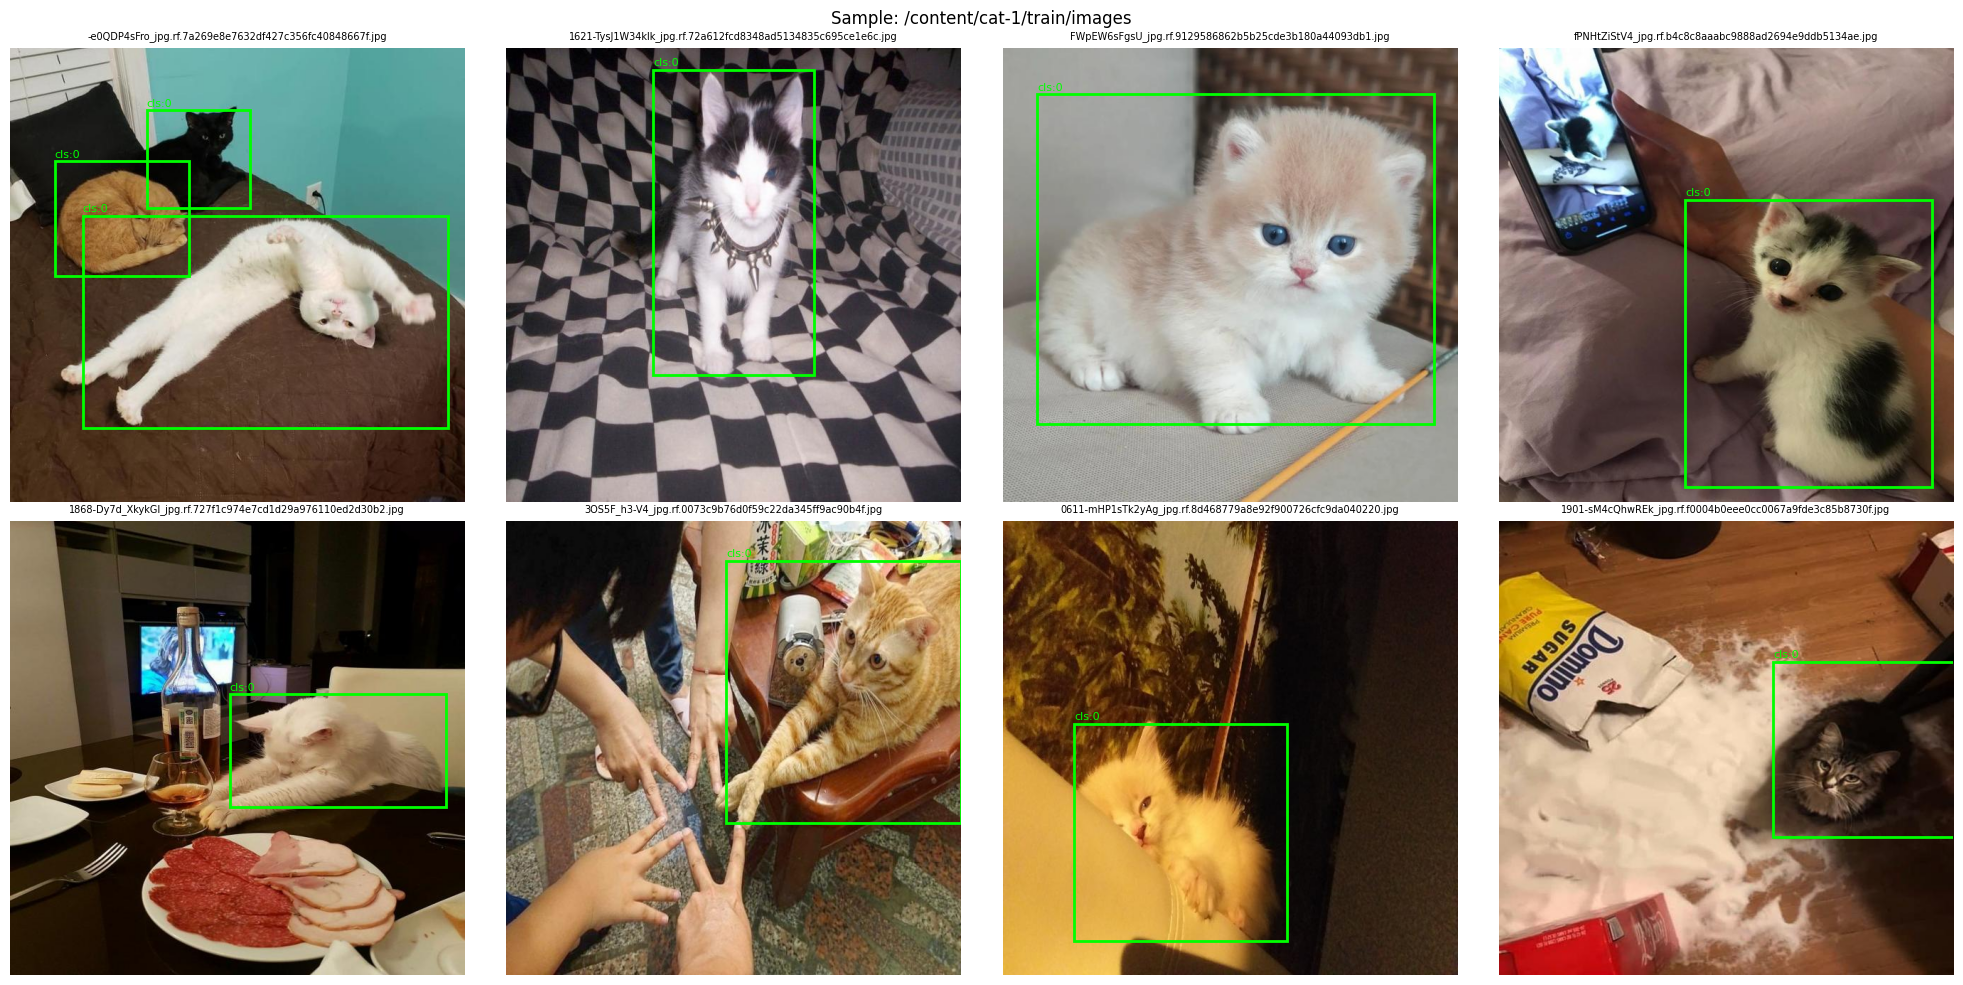


VISUAL CHECK - VALID samples:


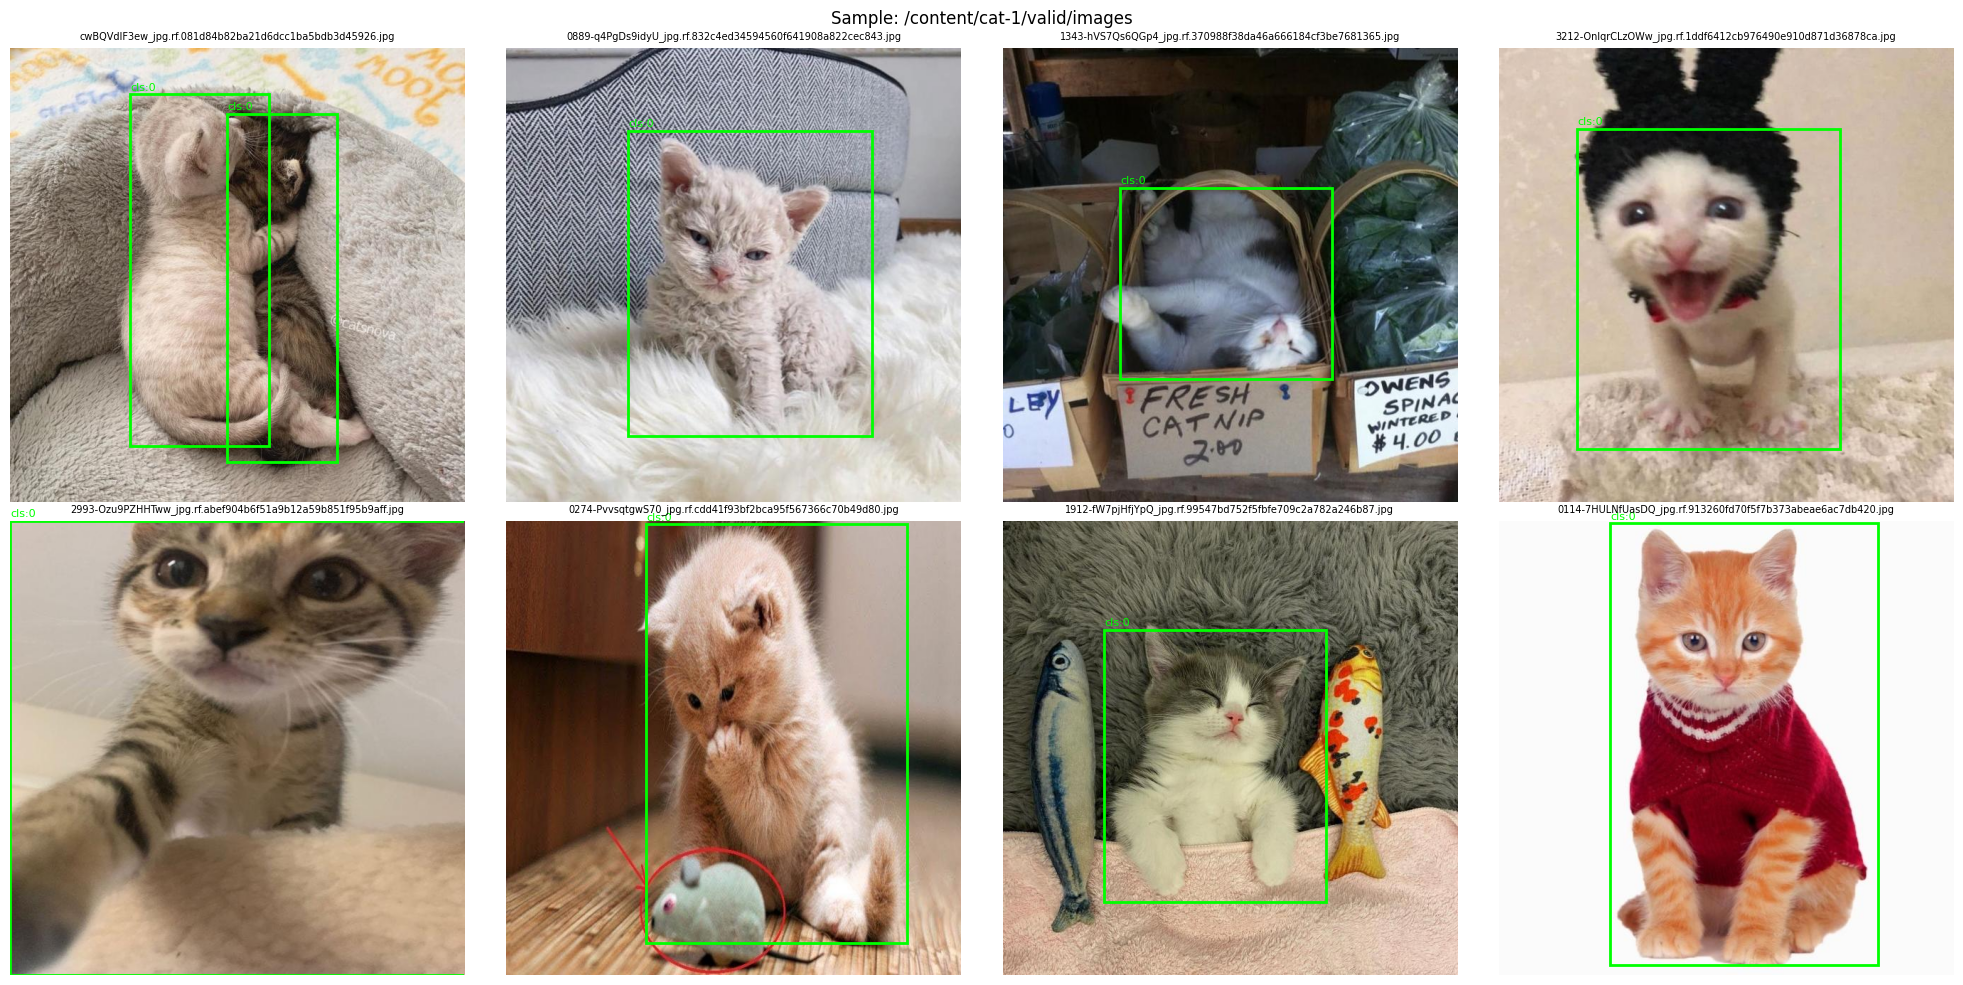

In [ ]:
# ============================================================
# DATA AUDIT CELL
# ============================================================
import os
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

TRAIN_IMG = "/content/cat-1/train/images"
TRAIN_LBL = "/content/cat-1/train/labels"
VALID_IMG = "/content/cat-1/valid/images"
VALID_LBL = "/content/cat-1/valid/labels"

def audit_split(img_dir, lbl_dir, split_name):
    print(f"\n{'='*50}")
    print(f"AUDIT: {split_name}")
    print('='*50)

    img_files = set(Path(img_dir).glob("*.*"))
    lbl_files = set(Path(lbl_dir).glob("*.txt"))

    img_stems = {f.stem for f in img_files}
    lbl_stems = {f.stem for f in lbl_files}

    missing_labels = img_stems - lbl_stems
    missing_images = lbl_stems - img_stems

    print(f"Images:          {len(img_stems)}")
    print(f"Labels:          {len(lbl_stems)}")
    print(f"Missing labels:  {len(missing_labels)}")
    print(f"Missing images:  {len(missing_images)}")

    if missing_labels:
        print(f"  !! No label for: {list(missing_labels)[:5]}")
    if missing_images:
        print(f"  !! No image for: {list(missing_images)[:5]}")

    # Label stats
    empty_labels = []
    bad_format = []
    box_counts = []
    class_counts = defaultdict(int)
    tiny_boxes = []
    huge_boxes = []

    for lbl_path in Path(lbl_dir).glob("*.txt"):
        lines = lbl_path.read_text().strip().splitlines()
        lines = [l for l in lines if l.strip()]

        if len(lines) == 0:
            empty_labels.append(lbl_path.name)
            continue

        box_counts.append(len(lines))

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                bad_format.append((lbl_path.name, line))
                continue
            try:
                cls, cx, cy, w, h = map(float, parts)
                class_counts[int(cls)] += 1

                # Sanity checks
                if not all(0.0 <= v <= 1.0 for v in [cx, cy, w, h]):
                    bad_format.append((lbl_path.name, f"OUT OF RANGE: {line}"))
                if w * h < 0.001:
                    tiny_boxes.append((lbl_path.name, w, h))
                if w > 0.95 or h > 0.95:
                    huge_boxes.append((lbl_path.name, w, h))
            except:
                bad_format.append((lbl_path.name, line))

    print(f"\nEmpty label files: {len(empty_labels)}")
    if empty_labels:
        print(f"  {empty_labels[:5]}")
    print(f"Bad format lines:  {len(bad_format)}")
    if bad_format:
        print(f"  {bad_format[:3]}")
    print(f"Tiny boxes (<0.1% area): {len(tiny_boxes)}")
    if tiny_boxes:
        print(f"  {tiny_boxes[:3]}")
    print(f"Huge boxes (>95% frame): {len(huge_boxes)}")
    if huge_boxes:
        print(f"  {huge_boxes[:3]}")
    print(f"\nBoxes per image: min={min(box_counts) if box_counts else 0}, "
          f"max={max(box_counts) if box_counts else 0}, "
    )
    avg = np.mean(box_counts) if box_counts else 0
    print(f"Boxes per image: min={min(box_counts) if box_counts else 0}, "
    f"max={max(box_counts) if box_counts else 0}, "
    f"avg={avg:.1f}")
    print(f"Class distribution: {dict(class_counts)}")

    return img_files

def visualize_samples(img_dir, lbl_dir, n=8):
    """Draw bboxes on random samples - eyeball check"""
    img_paths = list(Path(img_dir).glob("*.*"))
    sample = np.random.choice(img_paths, min(n, len(img_paths)), replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for ax, img_path in zip(axes, sample):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = Path(lbl_dir) / (img_path.stem + ".txt")
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=7)
        ax.axis('off')

        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, cx, cy, bw, bh = map(float, parts)
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw*w, bh*h,
                    linewidth=2, edgecolor='lime', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1-5, f"cls:{int(cls)}", color='lime', fontsize=8)
        else:
            ax.set_title(f"NO LABEL: {img_path.name}", color='red', fontsize=7)

    plt.suptitle(f"Sample: {img_dir}", fontsize=12)
    plt.tight_layout()
    plt.show()

# Run audit
audit_split(TRAIN_IMG, TRAIN_LBL, "TRAIN")
audit_split(VALID_IMG, VALID_LBL, "VALID")

# Visual check
print("\nVISUAL CHECK - TRAIN samples:")
visualize_samples(TRAIN_IMG, TRAIN_LBL, n=8)

print("\nVISUAL CHECK - VALID samples:")
visualize_samples(VALID_IMG, VALID_LBL, n=8)

In [ ]:
import zipfile
import os

def folder_to_zip(folder_path, zip_filename):
    """Convert folder to zip"""
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)
    print(f"✓ Created {zip_filename}")

# Usage
folder_to_zip('/content/cat_detection', 'cat_detection.zip')

✓ Created cat_detection.zip


In [ ]:
import zipfile
import os

def folder_to_zip(folder_path, zip_filename):
    """Convert folder to zip"""
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)
    print(f"✓ Created {zip_filename}")

# Usage
folder_to_zip('/content/cat_detection_yolov8', 'cat_detection_file.zip')

In [ ]:
import shutil
import os

# Create a folder for zip files
zip_folder = '/content/zip_files'
os.makedirs(zip_folder, exist_ok=True)

# Create zip file in that folder
zip_path = os.path.join(zip_folder, 'cat_detection.zip')
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/content', 'cat_detection')
print(f"✓ Created {zip_path}")

✓ Created /content/zip_files/cat_detection.zip



image 1/1 /content/test/gettyimages-1500448395-612x612.jpg: 448x640 1 Cats, 76.2ms
Speed: 4.6ms preprocess, 76.2ms inference, 9.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/cat_detection_yolov8/unseen_test


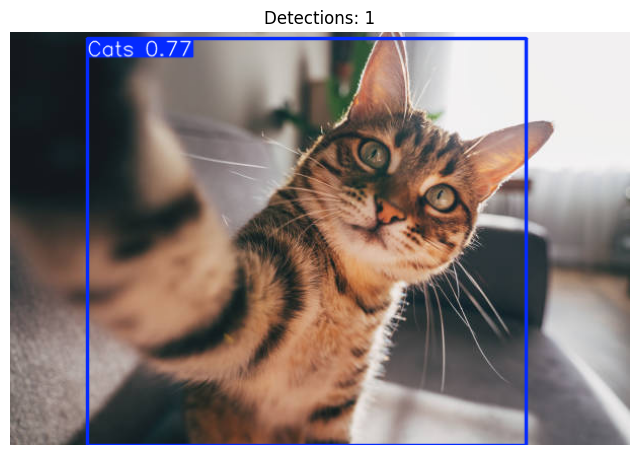

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

model = YOLO('/content/cat_detection_yolov8/yolov8s_augmented/weights/best.pt')

# point to any folder of unseen images
TEST_DIR = '/content/test'  # change this

results = model.predict(
    source=TEST_DIR,
    conf=0.25,
    iou=0.45,
    save=True,
    save_conf=True,
    project='/content/cat_detection_yolov8',
    name='unseen_test',
)

# show results inline
for r in results[:6]:
    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Detections: {len(r.boxes)}")
    plt.axis('off')
    plt.show()